# Task 1 : Dataset Understanding

In [33]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
#Step 1: Load the netflix dataset
df = pd.read_csv('netflix_titles.csv')

#Peak at the first 5 rows
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [35]:
# Step 2: Number of rows and columns in the dataset
print("Shape(rows, columns):", df.shape)
# Data types of each column
print("\nData types:\n", df.dtypes)
# Quick summary: column names, non null counts dtypes
df.info()

Shape(rows, columns): (8807, 12)

Data types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  descr

In [36]:
# Step 3: Check if show_id is truly unique (a valid primary key candidate)
print("Total rows:", len(df))
print("Unique show_id values:", df['show_id'].nunique())

# Look at unique values in key categorical columns
print("\nUnique 'type' values:", df['type'].unique())
print("Number of unique countries:", df['country'].nunique())
print("Number of unique ratings:", df['rating'].nunique())

Total rows: 8807
Unique show_id values: 8807

Unique 'type' values: ['Movie' 'TV Show']
Number of unique countries: 748
Number of unique ratings: 17


### 1. Loading the Data
We loaded the dataset using `pd.read_csv('netflix_titles.csv')` and viewed the first
5 rows with `.head()`. This is always the first step before touching any data —
you need to see the raw shape of things before deciding how to clean or analyze it.

From the first look, we could already spot a few things worth flagging for later:
- `director` and `cast` had missing (`NaN`) values in several rows.
- `country` was also blank in some rows.
- `date_added` was stored as a text string (e.g. `"September 25, 2021"`), not a real date.
- `duration` mixes two different units depending on content type — `"90 min"` for
  Movies, but `"2 Seasons"` for TV Shows.

### 2. Number of Rows and Columns
Using `.shape`, we found the dataset has:
- **8,807 rows** (each row = one Netflix title)
- **12 columns**

### 3. Data Types
Using `.dtypes` and `.info()`, we found:

| Column | Dtype |
|---|---|
| show_id | object (text) |
| type | object |
| title | object |
| director | object |
| cast | object |
| country | object |
| date_added | object |
| release_year | int64 |
| rating | object |
| duration | object |
| listed_in | object |
| description | object |

Only `release_year` is stored as a true number (`int64`). Everything else — even
things that *look* numeric, like `duration` (`"90 min"`) — is stored as plain text
(`object`), because it's mixed with words. This is a big reason `.dtypes` matters:
pandas won't automatically know a column is "numeric" if it contains any text at all.

`.info()` also showed us **non-null counts per column**, which is our first hint at
missing data:
- `director`: 6,173 non-null (→ 2,634 missing)
- `cast`: 7,982 non-null (→ 825 missing)
- `country`: 7,976 non-null (→ 831 missing)
- `date_added`: 8,797 non-null (→ 10 missing)
- `rating`: 8,803 non-null (→ 4 missing)
- `duration`: 8,804 non-null (→ 3 missing)

We'll quantify and handle these properly in Task 2 — for now we just noted they exist.

### 4. Feature Classification
Based on the data types and the number of unique values in each column, we classified
the columns as follows:

- **Numerical feature:** `release_year`
- **Categorical features:** `type` (Movie/TV Show), `country`, `rating`, `listed_in` (genres) —
  these repeat across many rows and form a limited set of categories.
- **Free text fields:** `title`, `director`, `cast`, `description` — mostly unique
  per row, not "categories" in the analytical sense.
- **Primary key (unique identifier):** `show_id` — confirmed by checking that
  `nunique()` on `show_id` equals the total row count (8,807), meaning every value
  is unique and no two rows share an ID.

### 5. What the Dataset Contains
This dataset lists 8,807 titles available on Netflix (Movies and TV Shows combined)
as of the date the data was collected. Each row represents one title and includes
its director, cast, country of production, the date it was added to Netflix, its
original release year, content rating (e.g. PG-13, TV-MA), duration, genre(s) under
`listed_in`, and a short plot description.

This data is useful for answering questions like: What type of content dominates
Netflix's library? Which countries produce the most content? How has the catalog
grown over time? What are the most common genres and ratings? These are exactly
the questions we'll explore in the EDA stage (Task 3).

**Conclusion:** Task 1 gave us a clear picture of the dataset's structure and
confirmed several issues to address next — missing values in `director`, `cast`,
`country`, `date_added`, `rating`, and `duration`; a `date_added` column that needs
converting to a real date type; and a `duration` column that mixes two different
units depending on content type. These become our roadmap for Task 2: Data Cleaning.

# Task 2: Data Cleaning

In [37]:
#Step 1: Count of missing values per column  
missing_counts = df.isnull().sum()

# Percentage of missing values per column
missing_percentage = (df.isnull().sum()/ len(df)* 100)

# Combine into one table for easy reading
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %' :missing_percentage.round(2)
})

# Only show columns that have missing values sorted worst first
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending = False)


,Missing Count,Missing %
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


### Identifying Missing Values

We use `.isnull().sum()` to count missing values per column, and divide by the total
number of rows to get a percentage — the percentage matters more than the raw count,
because it tells us how *serious* the gap is relative to the whole dataset (2,634
missing values sounds big, but is it 5% of the data or 50%?).

We filter to only show columns with missing values > 0, and sort from worst to least,
so we tackle the biggest problems first.

In [38]:
# Fill the missing values with a clear placeholder
df['director'] = df['director'].fillna('Not Specified')
df['cast'] = df['cast'].fillna('Not Specified')
df['country'] = df['country'].fillna('Unknown')

# Confirm there are no more missing values in these columns
df[['director', 'cast', 'country']].isnull().sum()

director    0
cast        0
country     0
dtype: int64

### Handling Missing Values: director, cast, country

- `director` (29.91% missing) and `cast` (9.37% missing) were filled with `'Not Specified'`.
- `country` (9.44% missing) was filled with `'Unknown'`.

**Why fill instead of drop?**
Dropping every row with a missing `director` would remove almost a third of the
dataset — an unacceptable loss of data, especially since `director` isn't critical
to most of our planned analysis (genre trends, content growth, ratings). The missing
value itself is meaningful: it likely means Netflix's records didn't have that
information (common for documentaries, stand-up specials, and reality shows), not
that the data is "wrong."

**Why a placeholder instead of the mode (most frequent value)?**
For categorical columns like `director` or `country`, filling with the *mode* would
mean picking one specific director/country and pretending they made 2,634 titles they
didn't — that would badly distort any analysis on "top directors" or "top countries."
A clear placeholder like `'Not Specified'` keeps the row usable for other analyses
(e.g. genre, rating, release year) without falsely inflating any real category.



In [39]:
# Look at the actual rows with missing date_added, rating, or duration
df[df['date_added'].isnull() | 
           df['rating'].isnull() | 
           df['duration'].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Not Specified,"Oprah Winfrey, Ava DuVernay",Unknown,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Not Specified,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Not Specified,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,Not Specified,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,Not Specified,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Not Specified,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
6901,s6902,TV Show,Gunslinger Girl,Not Specified,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."


In [40]:
# Find rows where 'rating' actually contains a duration value (shifted data)
shifted_rows = df['rating'].isin(['74 min', '84 min', '66 min'])
df[shifted_rows][['title', 'rating', 'duration']]

,title,rating,duration
5541,Louis C.K. 2017,74 min,NaN
5794,Louis C.K.: Hilarious,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,66 min,NaN


### Data Validation: Detecting Shifted Values

While inspecting rows with missing `rating`/`duration`, we noticed something more
serious than a simple gap: some rows have a duration-looking value (e.g. `"74 min"`)
sitting in the `rating` column, while `duration` itself is blank. This is a data
entry/scraping error — the value shifted one column to the left. Before filling
anything, we must correct this misplacement, or we'd be treating a wrong value as
if it were a legitimate (if unusual) rating.

In [41]:
# Copy the misplaced value into 'duration', and clear the incorrect 'rating' value
misplaced = df['rating'].isin(['74 min', '84 min', '66 min'])

df.loc[misplaced, 'duration'] = df.loc[misplaced, 'rating']
df.loc[misplaced, 'rating'] = None

# Confirm the fix
df[df['title'].isin(['Louis C.K. 2017', 'Louis C.K.: Hilarious', 'Louis C.K.: Live at the Comedy Store'])][['title', 'rating', 'duration']]

,title,rating,duration
5541,Louis C.K. 2017,None,74 min
5794,Louis C.K.: Hilarious,None,84 min
5813,Louis C.K.: Live at the Comedy Store,None,66 min


### Correcting the Misplaced Values

We identified the three affected rows (all Louis C.K. specials, where `rating` held
`"74 min"`, `"84 min"`, or `"66 min"`), moved that value into the correct `duration`
column, and reset `rating` to missing (`None`) since we don't actually know the true
rating for these titles — we just know it isn't a duration value.

**Why this matters:** if we had left this as-is, our EDA on "most common ratings"
(Task 3) would have counted `"74 min"` as a rating category, which is factually wrong
and would quietly corrupt our results. Data validation isn't just about missing values —
it's about catching values that exist but are *in the wrong place* or *wrong type*.

In [42]:
# Re-check missing values now that we've corrected the shifted data
df[['rating', 'date_added', 'duration']].isnull().sum()

rating         7
date_added    10
duration       0
dtype: int64

### Re-checking Missing Values After Correction

After fixing the shifted values, we recount missing values in `rating`, `date_added`,
and `duration`. We expect `duration` to now be fully complete (0 missing), since the
3 rows that were missing it were exactly the Louis C.K. rows we just fixed. `rating`
should now show 7 missing (the original 4 + the 3 we intentionally cleared).

In [43]:
# Fill missing ratings with Not rated - a real industry standard category
df['rating'] = df['rating'].fillna('Not Rated')

# For date aded the 10 missing rows cant be inferred we have no way when a title was added so we drop those rows
df = df.dropna(subset = ['date_added'])

# Final check - confirm all missing values are gone
df.isnull().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### Final Missing Value Treatment: rating and date_added

- **`rating` (7 missing):** filled with `'Not Rated'`. This isn't a made-up placeholder —
  `"NR"`/`"UR"` (Not Rated/Unrated) already exist naturally in the ratings system, so
  this is a truthful, industry-standard label rather than a guess.
- **`date_added` (10 missing):** these rows were **dropped**, not filled. Unlike a
  rating, there's no reasonable way to infer *when* a specific title was added to
  Netflix — any value we picked would be fabricated. Since 10 rows is only 0.11% of
  8,807 rows, dropping them has virtually no impact on our analysis, and it's safer
  than guessing a date that would distort our "content added over time" trend (Task 3).

After this step, the dataset should have **zero missing values** across all columns.

In [44]:
# Check for fully duplicated rows
duplicate_count = df.duplicated().sum()
print("Number of fully duplicated rows:", duplicate_count)

# Check for duplocates based on title + type + country +release year catches same show listed twice een if show_id differes slightly
subset_duplicates = df.duplicated(subset = ['title', 'type', 'country', 'release_year']).sum()
print("Number of duplicates based on title/type/country/release_year:", subset_duplicates)


Number of fully duplicated rows: 0
Number of duplicates based on title/type/country/release_year: 0


### Identifying Duplicate Records

We check for duplicates two ways:
1. `.duplicated()` with no arguments checks if an **entire row** is an exact copy
   of another row across all 12 columns.
2. `.duplicated(subset=[...])` checks a smaller set of "identity" columns — title,
   type, country, and release year — because two rows could represent the same
   real-world title even if something trivial differs (e.g. a slightly different
   `show_id` from a data refresh, or a different description wording).

Since `show_id` is guaranteed unique (we confirmed this in Task 1), a full-row
duplicate check would almost never find anything — every row differs by at least
that one column. So the subset check is the more meaningful test here.

#### (iii) Standardization : (dates,text case, column names, data types)

In [45]:
# Convert date_added from text eg September 25 2021 to a real datetime type
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

# Confirm if the conersion worked
df['date_added'].dtype, df['date_added'].head()

(dtype('<M8[ns]'),
 0   2021-09-25
 1   2021-09-24
 2   2021-09-24
 3   2021-09-24
 4   2021-09-24
 Name: date_added, dtype: datetime64[ns])

### Standardizing Date Formats

`date_added` was stored as text (e.g. `"September 25, 2021"`), which meant pandas
had no idea it was a date — we couldn't sort by it, extract the year/month, or plot
a trend over time. We used `pd.to_datetime()` to convert it to a proper datetime type.

We also used `.str.strip()` first to remove any leading/trailing whitespace, since
inconsistent spacing is a common hidden cause of date parsing failures.

In [46]:
# Check for inconsistent white space or casing in key text columns
print(df['type'].unique())
print(df['country'].str.strip().str.title().unique()[:10])
print(df['rating'].unique())

['Movie' 'TV Show']
['United States' 'South Africa' 'Unknown' 'India'
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia'
 'United Kingdom' 'Germany, Czech Republic' 'Mexico' 'Turkey' 'Australia']
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'Not Rated' 'NR' 'TV-Y7-FV' 'UR']


### Checking Text Consistency Before Standardizing

Before blindly reformatting text, we first look at what's actually there. This
avoids two mistakes: (1) "fixing" something that wasn't broken, and (2) applying
a formatting rule that breaks a column where case is meaningful (e.g. `rating`
values like `"TV-MA"` are a fixed industry code — forcing them to Title Case or
lowercase would make them wrong, not cleaner).

In [47]:
# Column names are already lower case and clean but lets confirm formally
print("Column names:", df.columns.tolist())

# Consolidate overlapping 'unrated' categories in rating
df['rating'] = df['rating'].replace({'NR': 'Not Rated', 'UR': 'Not Rated'})

# Confirm conslidation
df['rating'].unique()

Column names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'Not Rated', 'TV-Y7-FV'], dtype=object)

### Column Names and Rating Category Consolidation

Column names were already lowercase, with no spaces or special characters, so no
renaming was needed — this is good practice we're simply confirming, not fixing.

For `rating`, we noticed three separate labels representing the same real-world
meaning: `'Not Rated'`, `'NR'`, and `'UR'`. These are inconsistent codings of the
same category (unrated content), so we consolidated all of them into a single
label, `'Not Rated'`. Left as-is, this would have silently split one true category
into three in our EDA (Task 3's "most common ratings" analysis), understating how
common unrated content actually is.

In [48]:
# Split duration into a number and a unit, based on content type
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(int)
df['duration_unit'] = df['duration'].apply(
    lambda x: 'min' if 'min' in x else 'Season(s)'
)

# Quick check: movies should show minutes, TV shows should show seasons
df[['type', 'duration', 'duration_int', 'duration_unit']].sample(8, random_state=1)

,type,duration,duration_int,duration_unit
7292,Movie,78 min,78,min
5855,TV Show,2 Seasons,2,Season(s)
7030,Movie,85 min,85,min
3458,TV Show,1 Season,1,Season(s)
7939,Movie,133 min,133,min
5240,Movie,107 min,107,min
1936,Movie,80 min,80,min
331,TV Show,1 Season,1,Season(s)


### Restructuring `duration` into Usable Numeric Data

The original `duration` column stored two different kinds of information as plain
text: minutes for Movies (`"90 min"`) and seasons for TV Shows (`"2 Seasons"`).
As text, this column was unusable for any numeric analysis (e.g. "average movie
length", or a histogram of movie durations).

We split it into two new columns:
- `duration_int`: the number extracted from the string (e.g. `90`, `2`), using a
  regex `(\d+)` that pulls out the digits, converted to an actual integer.
- `duration_unit`: a label (`'min'` or `'Season(s)'`) showing what that number means.

This keeps the original `duration` column intact (for reference/display) while
giving us a genuinely numeric column we can run statistics and visualizations on —
but only meaningfully **within** each `type` group, since 90 minutes and 2 seasons
aren't comparable numbers.

### Data Validation Outlies and impossible values

In [49]:
# Check release_year range - anything before Netflix existed, or in the future, is suspicious
print("Release year range:", df['release_year'].min(), "-", df['release_year'].max())

# Check duration_int range separately for Movies and TV Shows
print("\nMovie duration (min) range:")
print(df[df['type'] == 'Movie']['duration_int'].describe())

print("\nTV Show duration (seasons) range:")
print(df[df['type'] == 'TV Show']['duration_int'].describe())

Release year range: 1925 - 2021

Movie duration (min) range:
count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_int, dtype: float64

TV Show duration (seasons) range:
count    2666.000000
mean        1.751313
std         1.550176
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_int, dtype: float64


### Checking for Outliers and Impossible Values

We inspect `release_year` and `duration_int` for anything implausible:
- A `release_year` in the future, or absurdly early (e.g. before film even existed),
  would signal a data entry error.
- `duration_int` for Movies should fall in a believable range (a few minutes to
  maybe 5+ hours for a very long film); for TV Shows, season counts should be small
  whole numbers. Extremely large values in either would need investigation.

We use `.describe()` because it gives us min, max, mean, and standard deviation in
one call — a fast way to see whether the range or spread looks reasonable, before
deciding if outliers need special treatment (note: outliers here are just something
we **document**, not necessarily remove — a genuinely long documentary, or a show
with 20 seasons, is a real value, not an error).

### Data Validation: Conclusion

We checked `release_year` and `duration_int` for outliers or impossible values.
The ranges found (release years 1925–2021, movie durations 3–312 minutes, TV show
seasons 1–17) are all realistic — nothing indicates a data entry error or requires
removal. We conclude no further validation fixes are needed.

## Task 2 Summary Table

| Issue Found | Action Taken |
|---|---|
| Missing `director`/`cast` (29.91%/9.37%) | Filled with `'Not Specified'` |
| Missing `country` (9.44%) | Filled with `'Unknown'` |
| Missing `rating` (4 rows) | Filled with `'Not Rated'` |
| Missing `date_added` (10 rows) | Rows dropped (no way to infer a true date) |
| Shifted values in `rating`/`duration` (3 rows, e.g. `"74 min"` in `rating`) | Corrected by moving value to `duration`, resetting `rating` to missing, then filled |
| Duplicate records | Checked — 0 found, no action needed |
| `date_added` stored as text | Converted to proper `datetime64` type |
| Inconsistent rating categories (`NR`, `UR`, `Not Rated`) | Consolidated into a single `'Not Rated'` label |
| `duration` mixing minutes and seasons in one text column | Split into `duration_int` (numeric) and `duration_unit` (label) |
| Outliers in `release_year`/`duration_int` | Checked — all values plausible, no removal needed |

**Cleaning challenges encountered:** The most subtle issue wasn't a missing value at
all — it was **shifted data**, where three rows had a duration value sitting in the
`rating` column. This wouldn't have been caught by a simple missing-value count;
it only surfaced by manually inspecting the rows with missing `rating`/`duration`.
This is a good reminder that `.isnull().sum()` is a starting point, not the whole
validation process.

In [50]:
df.to_csv('netflix_titles_cleaned.csv', index=False)
print("Saved! Shape of cleaned dataset:", df.shape)

Saved! Shape of cleaned dataset: (8797, 14)


### Saving the Cleaned Dataset

We export the cleaned DataFrame to a new CSV file, `netflix_titles_cleaned.csv`,
keeping the original raw file untouched. `index=False` prevents pandas from writing
an extra unnamed column for the row index, which we don't need in the saved file.
This cleaned file is one of our required deliverables for submission.

# Task 3: Exploratory Data Analysis

In [51]:
# Summary statistics for numerical clumns
df[['release_year']].describe()

# Duration statistics split by type since minutes and seasons are not comparable
print("Movie duration stats (minutes):")
print(df[df['type'] == 'Movie']['duration_int'].agg(['mean','median','min','max','std']))

print("\nTV Show duration stats (seasons):")
print(df[df['type'] == 'TV Show']['duration_int'].agg(['mean', 'median', 'min', 'max', 'std']))

Movie duration stats (minutes):
mean       99.564998
median     98.000000
min         3.000000
max       312.000000
std        28.289504
Name: duration_int, dtype: float64

TV Show duration stats (seasons):
mean       1.751313
median     1.000000
min        1.000000
max       17.000000
std        1.550176
Name: duration_int, dtype: float64


### Summary Statistics for Numerical Columns

We generate mean, median, min, max, and standard deviation for our numerical data:
`release_year`, and `duration_int` (split by `type`, since minutes and seasons are
not the same unit and averaging them together would produce a meaningless number).

We already saw most of these numbers in Task 2's validation step — this section
formalizes them as the official "Summary Statistics" deliverable required by the
assignment.

In [52]:
# Count of movies vs Tv shows
type_counts = df['type'].value_counts()
print(type_counts)

# As percentages
type_percent = df['type'].value_counts(normalize=True)*100
print("\nAs percentages:\n", type_percent.round(2))

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

As percentages:
 type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


### Exploration 1: Movies vs TV Shows Distribution

We count how many titles fall into each `type` category, both as raw counts and
as percentages, to understand the balance of Netflix's catalog between Movies and
TV Shows.  
About 70/30 split — Movies dominate the catalog.

In [53]:
# Content Added by year
df['year_added'] = df['date_added'].dt.year

# Count titles added per year
content_by_year = df['year_added'].value_counts().sort_index()
print(content_by_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


### Findings: Content Added by Year

The counts show a clear growth pattern in Netflix's catalog:

- From 2008–2015, additions were minimal (2–82 titles per year) — Netflix's content
  library was still small during this period.
- Growth accelerates sharply from 2016 onward: 429 titles in 2016, jumping to 1,188
  in 2017, then 1,649 in 2018, and peaking at 2,016 titles added in **2019** — the
  single biggest year for content additions.
- After 2019, additions decline slightly: 1,879 in 2020 and 1,498 in 2021 (2021 is
  likely also undercounted since our dataset was collected partway through that year).

**Interpretation:** This pattern lines up with Netflix's well-known global expansion
and heavy investment in content (both licensed and original) between 2016 and 2019,
as it scaled internationally and competed for subscriber growth. The slight dip after
2019 could reflect either a real slowdown, a shift toward fewer-but-bigger releases,
or simply that our dataset's snapshot date cuts 2021 short. We'll visualize this as
a line chart in Task 4 to make the trend easier to read.

In [54]:
# Top producing countries
# Split the country column on commas, since some rows list multiple countries
countries_split = df['country'].str.split(', ')

# Explode turns each list into its own row, so multi-country titles count for each country
countries_exploded = countries_split.explode().str.strip()

# Count top countries, excluding 'Unknown'
top_countries = countries_exploded[countries_exploded != 'Unknown'].value_counts().head(10)
print(top_countries)

country
United States     3683
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


### Findings: Top Content-Producing Countries

After splitting multi-country entries and counting each country's individual
contribution, the top 10 content-producing countries are:

| Rank | Country | Titles |
|---|---|---|
| 1 | United States | 3,683 |
| 2 | India | 1,046 |
| 3 | United Kingdom | 803 |
| 4 | Canada | 445 |
| 5 | France | 393 |
| 6 | Japan | 317 |
| 7 | Spain | 232 |
| 8 | South Korea | 231 |
| 9 | Germany | 226 |
| 10 | Mexico | 169 |

**Interpretation:** The United States dominates by a wide margin, contributing more
than 3.5x as many titles as the second-place country. India's strong second-place
position reflects Netflix's major investment in Bollywood and regional Indian content
to capture that large market. The rest of the top 10 is a mix of major English-speaking
markets (UK, Canada) and strong international content hubs (France, Japan, South Korea,
Spain, Germany, Mexico) — showing Netflix's catalog leans heavily toward North America
but has meaningful representation from Europe, Asia, and Latin America. We'll visualize
this as a bar chart in Task 4.

In [55]:
# Most common ratings
# Count of titles per rating
rating_counts = df['rating'].value_counts()
print(rating_counts)

rating
TV-MA        3205
TV-14        2157
TV-PG         861
R             799
PG-13         490
TV-Y7         333
TV-Y          306
PG            287
TV-G          220
Not Rated      89
G              41
TV-Y7-FV        6
NC-17           3
Name: count, dtype: int64


### Findings: Most Common Ratings

The distribution of content ratings across the catalog:

| Rating | Count | Meaning |
|---|---|---|
| TV-MA | 3,205 | Mature Audiences (TV) |
| TV-14 | 2,157 | Parents Strongly Cautioned (TV) |
| TV-PG | 861 | Parental Guidance (TV) |
| R | 799 | Restricted (Movie) |
| PG-13 | 490 | Parents Strongly Cautioned (Movie) |
| TV-Y7 | 333 | Directed to Older Children (TV) |
| TV-Y | 306 | All Children (TV) |
| PG | 287 | Parental Guidance (Movie) |
| TV-G | 220 | General Audience (TV) |
| Not Rated | 89 | Unrated |
| G | 41 | General Audience (Movie) |
| TV-Y7-FV | 6 | Older Children, Fantasy Violence (TV) |
| NC-17 | 3 | Adults Only (Movie) |

**Interpretation:** `TV-MA` is by far the most common rating, with 3,205 titles —
more than the next two ratings combined. Together, `TV-MA` and `TV-14` account for
roughly 61% of the entire catalog (5,362 of 8,797 titles), showing Netflix's content
is heavily skewed toward mature/teen-and-up audiences rather than young children.
Ratings aimed at young children (`TV-Y`, `TV-G`, `G`) make up a comparatively small
share, suggesting Netflix's core catalog strategy prioritizes adult and young-adult
viewers over a kids-first library. We'll visualize this as a bar chart in Task 4.

In [56]:
# Most common genres (listed_in)
# Split and explode listed in since titles can have multiple genres
genres_split = df['listed_in'].str.split(', ')
genres_exploded = genres_split.explode().str.strip()

# Count top genres
top_genres = genres_exploded.value_counts().head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


### Exploration 5: Most Common Genres

We applied the same split-and-explode technique used for `country`, since `listed_in`
also packs multiple genres into a single string (e.g. `"International TV Shows, TV
Dramas, TV Mysteries"`). Splitting on `', '` and exploding lets each genre a title
belongs to count independently, rather than treating each unique genre combination
as its own category.

**Top 10 genres:**

| Rank | Genre | Titles |
|---|---|---|
| 1 | International Movies | 2,752 |
| 2 | Dramas | 2,427 |
| 3 | Comedies | 1,674 |
| 4 | International TV Shows | 1,350 |
| 5 | Documentaries | 869 |
| 6 | Action & Adventure | 859 |
| 7 | TV Dramas | 762 |
| 8 | Independent Movies | 756 |
| 9 | Children & Family Movies | 641 |
| 10 | Romantic Movies | 616 |

**Interpretation:** "International Movies" is the single most common genre tag,
which aligns with our earlier finding that Netflix's catalog draws heavily from
countries beyond the US (India, UK, and others). "Dramas" and "Comedies" being
2nd and 3rd shows these remain the most universally produced content types
regardless of country. Notably, "Documentaries" (869) ranks higher than genres
like "Romantic Movies" (616), suggesting Netflix has invested significantly in
non-fiction content as a differentiator. We'll visualize this as a horizontal bar
chart in Task 4, since genre names are long and a horizontal layout reads better
than vertical bars.

This completes all 5 required explorations for Task 3:
1. Movies vs TV Shows distribution
2. Content added by year
3. Top content-producing countries
4. Most common ratings
5. Most common genres

# Data Visualization

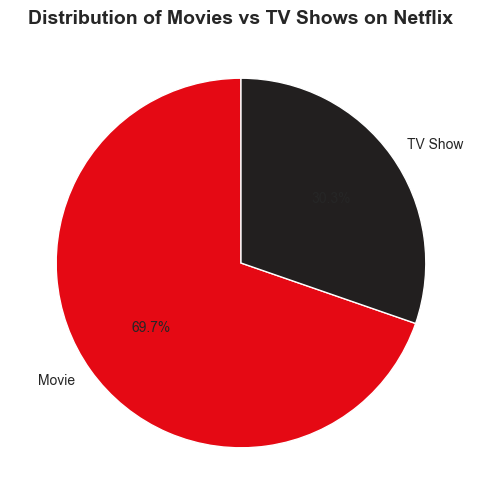

In [57]:
# Chart 1 : Movies Vs TV Shows
# Set a clean, consistent style for all our charts
sns.set_style('whitegrid')

# Chart 1: Movies vs TV Shows distribution (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', 
        colors=['#E50914', '#221f1f'], startangle=90)
plt.title('Distribution of Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.show()

### Chart 1: Movies vs TV Shows Distribution (Pie Chart)

This pie chart visualizes the type split we found in Task 3: **69.7% Movies** vs
**30.3% TV Shows**. A pie chart works well here because we're showing parts of a
whole with only two categories — easy to read as a simple proportion at a glance.

**Finding:** Netflix's catalog is dominated by movies, at more than double the
number of TV shows. This is useful context for later charts — since movies make
up the majority of titles, genres and countries associated mostly with movies will
naturally appear larger in our other visualizations too.

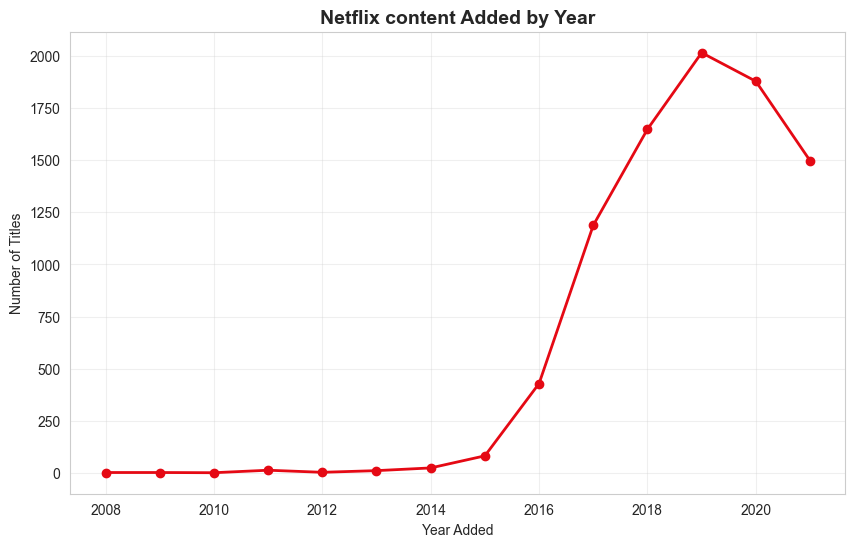

In [58]:
# Chart 2: Content added per year (line chart)
plt.figure(figsize=(10,6))
plt.plot(content_by_year.index, content_by_year.values, marker='o', color='#E50914', linewidth=2)
plt.title('Netflix content Added by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)
plt.show()

### Chart 2: Netflix Content Added by Year (Line Chart)

This line chart shows the number of titles added to Netflix each year from 2008
to 2021. A line chart is the right choice here because we're tracking a trend
over a continuous time axis — the shape of the line (not just individual points)
is what tells the story.

**Finding:** The chart makes Netflix's growth trajectory immediately visible —
a flat, near-zero line through 2015, then a sharp upward climb starting in 2016,
peaking at just over 2,000 titles in 2019, before declining through 2020 and 2021.
This visual confirms our earlier numeric finding: Netflix's period of most
aggressive content acquisition was 2016–2019, aligning with its major international
expansion years, with a pullback afterward (partly real slowdown, partly an
incomplete 2021 in our dataset's snapshot).

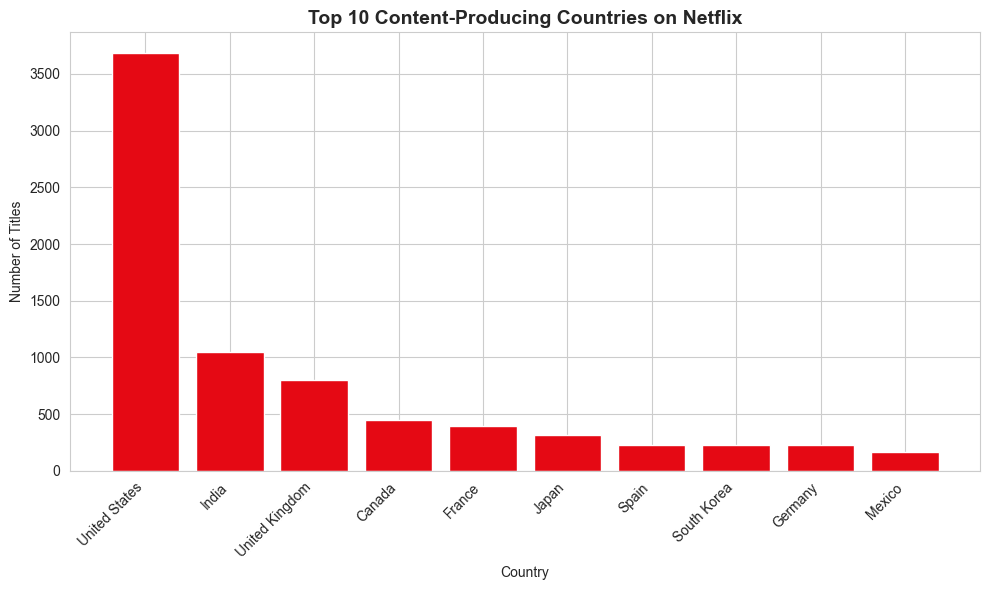

In [59]:
# Chart 3: Top 10 content-producing countries (Bar Chart)
plt.figure(figsize=(10, 6))
plt.bar(top_countries.index, top_countries.values, color='#E50914')
plt.title('Top 10 Content-Producing Countries on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 3: Top 10 Content-Producing Countries (Bar Chart)

This bar chart shows the top 10 countries by number of titles produced (after
splitting multi-country entries so each country is counted individually, as
explained in Task 3). A vertical bar chart works well for comparing a small,
ranked set of categories.

**Finding:** The United States towers over every other country, with roughly
3.5x as many titles as India in second place. After the top 3 (US, India, UK),
the remaining countries — Canada, France, Japan, Spain, South Korea, Germany,
Mexico — cluster closely together in the 150–450 title range, showing a steep
drop-off rather than a gradual decline. This confirms Netflix's catalog is
heavily US-centric, with India standing out as a clear second priority market.

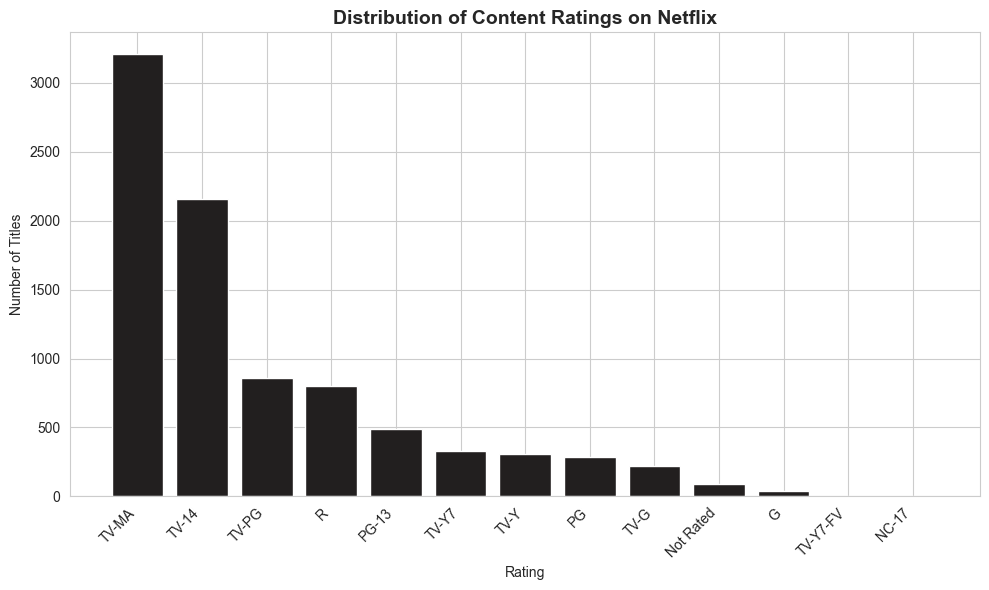

In [60]:
# Chart 4: Most common ratings (Bar Chart)
plt.figure(figsize=(10, 6))
plt.bar(rating_counts.index, rating_counts.values, color='#221f1f')
plt.title('Distribution of Content Ratings on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Chart 4: Distribution of Content Ratings (Bar Chart)

This bar chart shows the number of titles per content rating, ordered from most
to least common. A bar chart suits this well since ratings are discrete categories
being compared by count.

**Finding:** `TV-MA` and `TV-14` clearly dominate, together accounting for the
majority of the catalog, while ratings aimed at young children (`TV-G`, `G`,
`TV-Y7-FV`) barely register on the same scale. The sharp drop-off after the top
two bars visually confirms what we found in Task 3: Netflix's content strategy
is oriented toward teens and adults rather than young children.

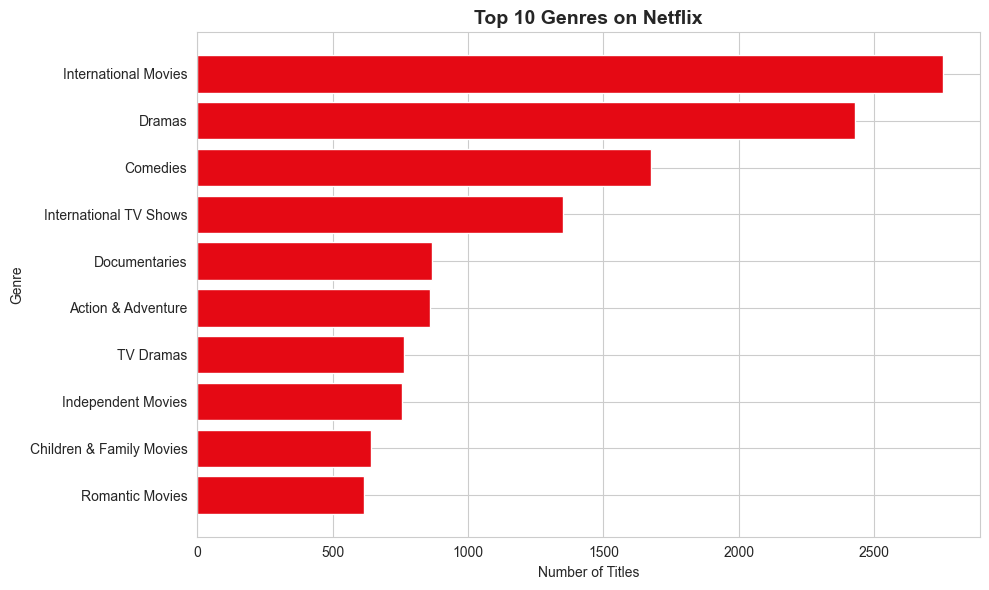

In [61]:
# Chart 5: Top 10 genres (Horizontal Bar Chart)
plt.figure(figsize=(10, 6))
plt.barh(top_genres.index[::-1], top_genres.values[::-1], color='#E50914')
plt.title('Top 10 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

### Chart 5: Top 10 Genres on Netflix (Horizontal Bar Chart)

This horizontal bar chart shows the 10 most common genres. We chose a horizontal
layout specifically because genre names like "Children & Family Movies" are long —
a vertical bar chart would force rotated, hard-to-read labels, while horizontal
bars let every label sit flat and legible.

**Finding:** "International Movies" leads narrowly over "Dramas," with "Comedies"
and "International TV Shows" close behind. The presence of two "international"
categories in the top 4 reinforces our earlier country-level finding: a large share
of Netflix's catalog is sourced from outside the US, even though the US alone is the
top single producing country. Genre-wise, drama and comedy remain the most
universally popular content types across the whole catalog.

This completes all 5 required visualizations for Task 4:
1. Movies vs TV Shows (Pie Chart)
2. Content Added by Year (Line Chart)
3. Top Content-Producing Countries (Bar Chart)
4. Content Ratings Distribution (Bar Chart)
5. Top 10 Genres (Horizontal Bar Chart)

# Task 5: Key Insights — Netflix Titles Dataset

**1. Netflix's catalog is movie-heavy, not TV-heavy.**
Movies make up 69.7% of all titles versus 30.3% for TV Shows (Chart 1). This matters
for interpreting every other insight — genres, countries, and ratings are all
weighted toward movie conventions simply because there are more than twice as many
movies as TV shows in the dataset.

**2. Netflix's most aggressive content growth happened between 2016 and 2019.**
Content additions were nearly flat through 2015, then rose sharply, peaking at over
2,000 titles added in 2019 (Chart 2). This lines up with Netflix's known global
expansion period. The decline in 2020–2021 could reflect a genuine strategic shift
toward fewer, bigger titles, or simply that our dataset's collection date cut 2021
short — we can't fully separate these two explanations from this data alone.

**3. Content production is heavily concentrated in the United States, with India a distant second.**
The US contributes roughly 3.5x as many titles as India, the next-highest country
(Chart 3). After the top 3 countries (US, India, UK), the remaining top 10 cluster
tightly together, suggesting a small handful of "priority" markets rather than an
evenly distributed global catalog.

**4. The catalog skews toward mature and teen audiences, not young children.**
TV-MA and TV-14 together account for roughly 61% of all titles (Chart 4), while
ratings for young children (TV-Y, TV-G, G) are a small minority. This suggests
Netflix's core content strategy targets adult and teen viewers rather than
positioning itself as a kids-first platform.

**5. "International" content is a defining feature of the catalog, not a niche category.**
Two of the top 4 genres are explicitly international ("International Movies" and
"International TV Shows"), and this aligns with the country-level finding that a
meaningful share of content originates outside the US (Chart 3, Chart 5). Combined
with Drama and Comedy leading the genre list, Netflix's catalog strategy appears to
balance broad, universally appealing genres with deliberate international sourcing.